# Árbol de Decisión — Enfermedad de Carrión (MINSA 2000–2024)

Clasificación de la **fase** de la enfermedad de Carrión (bartonelosis humana):
`AGUDA` (0) vs `ERUPTIVA` (1), con un árbol de decisión de scikit-learn.

Sigue la misma metodología del notebook del Titanic, aplicada a una fuente de
datos peruana del MINSA (46,121 registros). Se usan 5 features: edad, sexo,
departamento, año y semana epidemiológica.

## 1. Librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
from sklearn import tree
training = pd.read_csv("comparador-ml/data/carrion-train.csv")
training.info()

<class 'pandas.DataFrame'>
RangeIndex: 36896 entries, 0 to 36895
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   departamento  36896 non-null  str    
 1   provincia     36896 non-null  str    
 2   distrito      36896 non-null  str    
 3   localidad     36699 non-null  str    
 4   enfermedad    36896 non-null  str    
 5   ano           36896 non-null  int64  
 6   semana        36896 non-null  int64  
 7   diagnostic    36896 non-null  str    
 8   diresa        36896 non-null  int64  
 9   ubigeo        36896 non-null  int64  
 10  localcod      7829 non-null   float64
 11  edad          36896 non-null  int64  
 12  tipo_edad     36896 non-null  str    
 13  sexo          36896 non-null  str    
dtypes: float64(1), int64(5), str(8)
memory usage: 3.9 MB


## 2. Preprocesamiento

- `edad` → años según `tipo_edad` (A=años, M=meses, D=días).
- `sexo`: M=0, F=1.
- `departamento`: codificación numérica (label encoding alfabético, 0–18).
- `enfermedad` → target binario: AGUDA=0, ERUPTIVA=1.

Definimos una función `preparar()` para aplicar el MISMO preprocesamiento al
conjunto de entrenamiento y al de prueba.

In [2]:
DEPARTAMENTOS = ["AMAZONAS","ANCASH","APURIMAC","AYACUCHO","CAJAMARCA","CUSCO",
 "HUANUCO","JUNIN","LA LIBERTAD","LAMBAYEQUE","LIMA","LORETO","MADRE DE DIOS",
 "PASCO","PIURA","PUNO","SAN MARTIN","TACNA","UCAYALI"]
depto_idx = {d: i for i, d in enumerate(DEPARTAMENTOS)}
columnas = ["edad_anios", "sexo_cod", "depto_cod", "ano", "semana"]

def edad_anios(e, t):
    t = str(t).upper()
    return e/12 if t == "M" else (e/365 if t == "D" else float(e))

def preparar(df):
    df = df[df["enfermedad"].isin(["ENFERMEDAD DE CARRION AGUDA",
                                   "ENFERMEDAD DE CARRION ERUPTIVA"])].copy()
    df["edad_anios"] = df.apply(lambda r: edad_anios(r["edad"], r["tipo_edad"]), axis=1)
    df["sexo_cod"]   = df["sexo"].apply(lambda s: 0 if str(s).upper() == "M" else 1)
    df["depto_cod"]  = df["departamento"].apply(lambda d: depto_idx[str(d).upper()])
    df["target"]     = df["enfermedad"].map({"ENFERMEDAD DE CARRION AGUDA": 0,
                                             "ENFERMEDAD DE CARRION ERUPTIVA": 1})
    X = df[columnas].values
    Y = df["target"].values
    return X, Y

X, Y = preparar(training)
print("X:", X.shape, " Y:", Y.shape)

X: (36896, 5)  Y: (36896,)


## 3. Entrenamiento del árbol (criterio de entropía)

In [3]:
miarbol = tree.DecisionTreeClassifier(criterion="entropy", random_state=42)
miarbol = miarbol.fit(X, Y)
print("Accuracy entrenamiento:", 100*miarbol.score(X, Y))
Ypredecido = miarbol.predict(X)

Accuracy entrenamiento: 93.17270164787512


Predicción individual de ejemplo: hombre de 20 años, Áncash (1), año 2004, semana 31.

In [4]:
# columnas = [edad_anios, sexo_cod, depto_cod, ano, semana]
respuesta = miarbol.predict([[20.0, 0, 1, 2004, 31]])
print(respuesta)

[0]


## 4. Visualización del árbol

El árbol completo es muy grande (memoriza el entrenamiento), así que se muestran
solo los primeros 3 niveles con `plot_tree` de scikit-learn (equivalente a
`export_graphviz`, pero sin requerir el binario Graphviz).

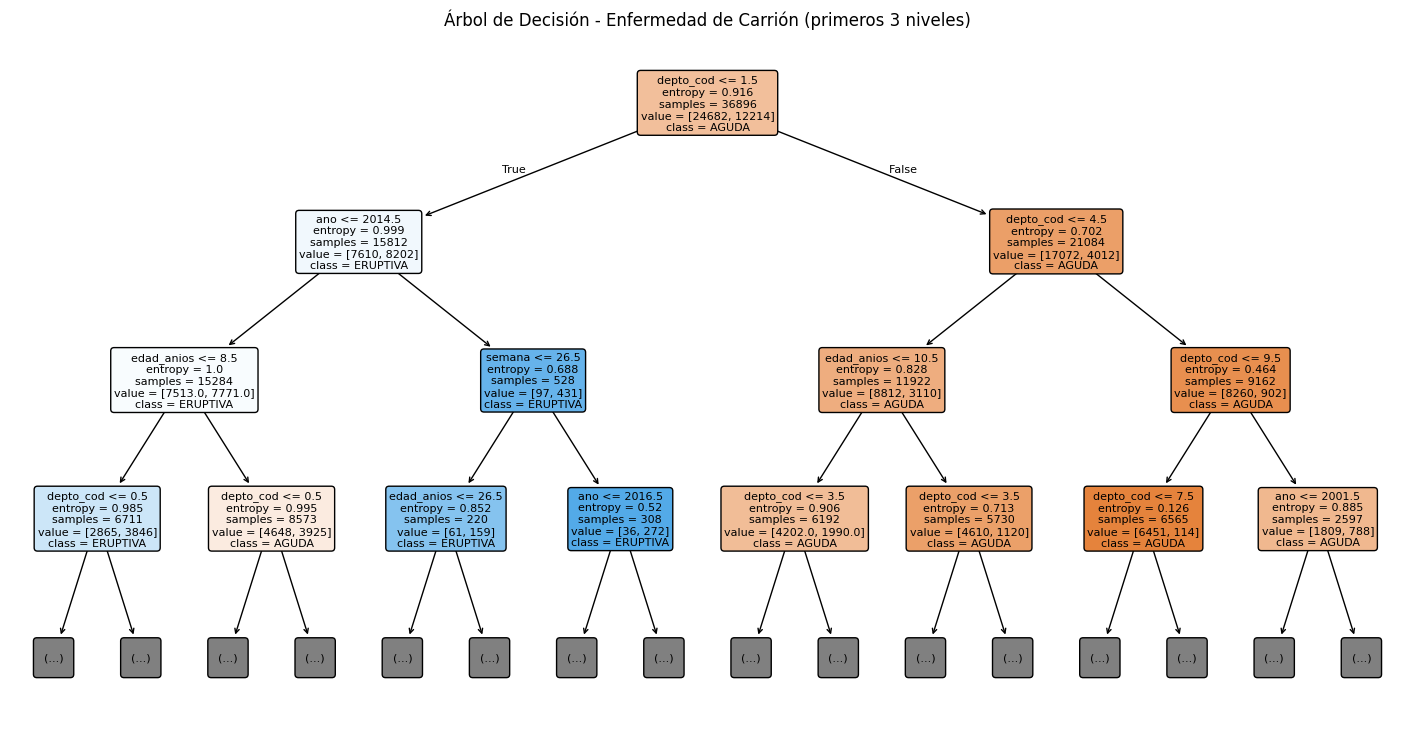

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(18, 9))
plot_tree(miarbol, max_depth=3, feature_names=columnas,
          class_names=["AGUDA", "ERUPTIVA"], filled=True, fontsize=8, rounded=True)
plt.title("Árbol de Decisión - Enfermedad de Carrión (primeros 3 niveles)")
plt.show()

## 5. Evaluación con el conjunto de prueba

In [6]:
testing = pd.read_csv("comparador-ml/data/carrion-test.csv")
Xtest, Ytest = preparar(testing)
Ypred_test = miarbol.predict(Xtest)
print("Accuracy prueba:", 100*miarbol.score(Xtest, Ytest))

Accuracy prueba: 67.16175195143104


In [7]:
from sklearn.metrics import confusion_matrix
Matriz = confusion_matrix(Ytest, Ypred_test)
# sensibilidad
sensibilidad = Matriz[0,0] / np.sum(Matriz[0,0] + Matriz[1,0])
print("Sensibilidad:", sensibilidad)

Sensibilidad: 0.7475957748699353


In [8]:
# especificidad
especificidad = Matriz[1,1] / np.sum(Matriz[1,1] + Matriz[0,1])
print("Especificidad:", especificidad)

Especificidad: 0.5043387712599792


Matriz de confusion - Conjunto de prueba
 [[4742 1428]
 [1601 1453]]
Metricas
               precision    recall  f1-score   support

       AGUDA       0.75      0.77      0.76      6170
    ERUPTIVA       0.50      0.48      0.49      3054

    accuracy                           0.67      9224
   macro avg       0.63      0.62      0.62      9224
weighted avg       0.67      0.67      0.67      9224



C:\Users\Usuario\AppData\Local\Temp\ipykernel_5748\2966122741.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_5748\2966122741.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels)


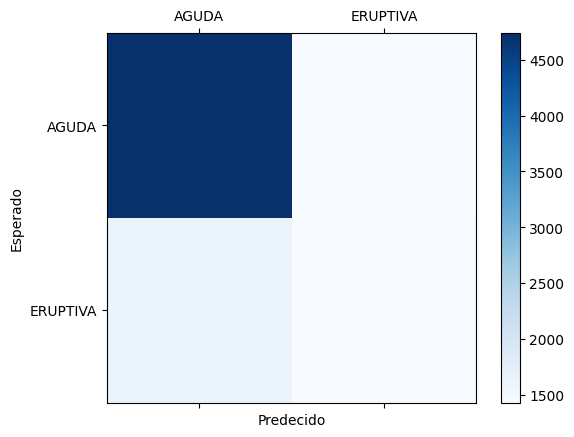

In [9]:
from sklearn.metrics import classification_report
conf_mat = confusion_matrix(y_true=Ytest, y_pred=Ypred_test)
print("Matriz de confusion - Conjunto de prueba\n", conf_mat)
print("Metricas\n", classification_report(Ytest, Ypred_test, target_names=["AGUDA","ERUPTIVA"]))
labels = ['AGUDA', 'ERUPTIVA']
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.Blues)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predecido')
plt.ylabel('Esperado')
plt.show()

## 6. Guardar y cargar el modelo (pickle)

In [10]:
import pickle
with open('miarbolcarrion.pkl', 'wb') as outfile:
    pickle.dump(miarbol, outfile)
print("Arbol aprendido guardado correctamente")

Arbol aprendido guardado correctamente


In [11]:
with open("miarbolcarrion.pkl", "rb") as tf:
    miarbol_cargado = pickle.load(tf)
print("Arbol aprendido cargado correctamente")

Arbol aprendido cargado correctamente


## 7. Diagnóstico

In [12]:
def diagnostico(valor):
    print(valor)
    if valor == 1:
        return "Carrion ERUPTIVA (fase cronica/cutanea)"
    else:
        return "Carrion AGUDA (fase febril/anemica)"

respuesta = miarbol_cargado.predict([[20.0, 0, 1, 2004, 31]])
print(diagnostico(respuesta[0]))

0
Carrion AGUDA (fase febril/anemica)
